# MARL Notebook

### Using Jax for speedy reinforcement learning

Motivation: After developing our environment and training schedule, we ran into time and compute constraints
- Could not run more than ~40 envs on our computer, which for many timesteps took hours

Solution: Use Jax (via MuJoCo Playground environments) to speed things up
- Run in Google collab to get around Jax GPU OS constraints (Jax GPU is meant to run on Linux)

### Background

Jax compiles Python code into optimized machine code (usually via XLA)
- Traces Python functions, builds computation graph, generates machine code for device (GPU in this case)
- Jax can then reuse compiled code, which (combined with GPU speed), makes computations very fast
  - Caveats: Have to make some adjustments (e.g. no inner for loops as they cannot be vectorized by Jax)

Since Jax/JIT traces operations and builds a computation graph, we want to keep things relatively simple to avoid long computations
- Created a new Crazyflie XML without all the collision geoms to speed things up
  - Previously, the physics integrator had to consider all collisions even if we never actually collided with anything
  - We weren't using these geoms anyway, as we end training episodes if drone(s) get to close to the ground or one another ("crash" but no collision)

### Resources

[MuJoCo Playground](https://github.com/google-deepmind/mujoco_playground) with example [Cartpole Balance RL Notebook](https://colab.research.google.com/github/google-deepmind/mujoco_playground/blob/main/learning/notebooks/dm_control_suite.ipynb)


[Brax](https://github.com/google/brax) was used for PPO and as an example to build multi-agent PPO


In [1]:
#@title Install pre-requisites
!pip install mujoco
!pip install mujoco_mjx
!pip install brax
!pip install playground

# Rendering video
!command -v ffmpeg >/dev/null || (apt update && apt install -y ffmpeg)
!pip install -q mediapy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 737.0/737.0 kB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 344.1/344.1 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.4/172.4 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.9 MB/s eta 0:00:00


In [2]:
# @title Check if MuJoCo installation was successful and ensure correct config

import distutils.util
import os
import subprocess

if subprocess.run('nvidia-smi').returncode:
  raise RuntimeError(
      'Cannot communicate with GPU. '
      'Make sure you are using a GPU Colab runtime. '
      'Go to the Runtime menu and select Choose runtime type.'
  )

# Add an ICD config so that glvnd can pick up the Nvidia EGL driver.
# This is usually installed as part of an Nvidia driver package, but the Colab
# kernel doesn't install its driver via APT, and as a result the ICD is missing.
# (https://github.com/NVIDIA/libglvnd/blob/master/src/EGL/icd_enumeration.md)
NVIDIA_ICD_CONFIG_PATH = '/usr/share/glvnd/egl_vendor.d/10_nvidia.json'
if not os.path.exists(NVIDIA_ICD_CONFIG_PATH):
  with open(NVIDIA_ICD_CONFIG_PATH, 'w') as f:
    f.write("""{
    "file_format_version" : "1.0.0",
    "ICD" : {
        "library_path" : "libEGL_nvidia.so.0"
    }
}
""")

# Configure MuJoCo to use the EGL rendering backend (requires GPU)
print('Setting environment variable to use GPU rendering:')
%env MUJOCO_GL=egl

try:
  print('Checking that the installation succeeded:')
  import mujoco

  mujoco.MjModel.from_xml_string('<mujoco/>')
except Exception as e:
  raise e from RuntimeError(
      'Something went wrong during installation. Check the shell output above '
      'for more information.\n'
      'If using a hosted Colab runtime, make sure you enable GPU acceleration '
      'by going to the Runtime menu and selecting "Choose runtime type".'
  )

print('Installation successful.')

# Tell XLA to use Triton GEMM, this improves steps/sec by ~30% on some GPUs
xla_flags = os.environ.get('XLA_FLAGS', '')
xla_flags += ' --xla_gpu_triton_gemm_any=True'
os.environ['XLA_FLAGS'] = xla_flags

Setting environment variable to use GPU rendering:
env: MUJOCO_GL=egl
Checking that the installation succeeded:
Installation successful.


## Load XML Scenes

We are using simplified versions of the MuJoCo menagerie crazyflie model without collisions to reduce Jax graph computations. We don't use collisions anyway, since the env terminates if drones are near the ground / other drones.

### Option 1: Load from Google drive

In [3]:
# Run this cell if the assets are loaded in a mounted Google drive

# Importing Scene from Google Drive (mounted folder)
SCENE_PATH_1_DRONE = "/content/drive/MyDrive/assets_mjx/bitcraze_crazyflie_2/scene.xml"
SCENE_PATH_2_DRONES = "/content/drive/MyDrive/assets_mjx/bitcraze_crazyflie_2/scene_multi.xml"

### Option 2: Upload from .ZIP

In [ ]:
# Load this cell to upload an assets_mjx.zip folder with the scenes
# The assets_mjx folder is available in the UOttawa MIRL repo for this project

from google.colab import files
import zipfile
import os

# Upload the zip file
print("Upload your assets_mjx.zip file:")
uploaded = files.upload()

zip_name = next(iter(uploaded))
print(f"Uploaded: {zip_name}")

extract_dir = "/content/assets_mjx"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall(extract_dir)

print(f"Extracted to: {extract_dir}")

# Set scene paths (matching your original structure)
SCENE_PATH_1_DRONE = "/content/assets_mjx/assets_mjx/bitcraze_crazyflie_2/scene.xml"
SCENE_PATH_2_DRONES = "/content/assets_mjx/assets_mjx/bitcraze_crazyflie_2/scene_multi.xml"

print("Scene paths set.")

Upload your assets_mjx.zip file:


Saving assets_mjx.zip to assets_mjx (1).zip
Uploaded: assets_mjx (1).zip
Extracted to: /content/assets_mjx
Scene paths set.


## Crazyflie Config and Helpers

In [4]:
from mujoco_playground._src import mjx_env
import mujoco
from mujoco import mjx
import jax
import jax.numpy as jnp
import numpy as np
from ml_collections import config_dict

import mediapy as media
from typing import Any

# Base target pos and training range (starting pos range for target & drones)
TARGET_POS = jnp.array([0.0, 0.0, 1.0])
TRAINING_POS_RANGE = 2.0

# Basic info
BASE_HOVER_THRUST = 0.26487
QPOS_PER_DRONE = 7  # pos + quat
QVEL_PER_DRONE = 6  # linear vel + angular vel
ACTION_SIZE_PER_DRONE = 4 # Thrust, roll, pitch, yaw
N_PREV_ACTIONS = 1 # Store N previous actions in. obs

# Random starting state sampled from distribution
TRAINING_QUAT_RANGE = np.pi / 8
TRAINING_VEL_RANGE = 0.2
TRAINING_ANG_VEL_RANGE = 0.1

# Out of bounds if N distance further from target compared to starting distance
OUT_OF_BOUNDS_RANGE = 2.0

# Reward and observation constants
TERMINATION_WEIGHT = 1.0
SURVIVAL_WEIGHT = TERMINATION_WEIGHT / 1000
DRONE_PROXIMITY_WEIGHT = 0.01
TARGET_PROXIMITY_WEIGHT = 0.01

DRONE_PROXIMITY_THRESHOLD = 0.2
DRONE_COLLISION_THRESHOLD = 0.05

def clipped_normal(rng, shape, std, std_clip=3.0):
    """
    Helper function to clip a normal distribution within n standard deviations
    """
    noise = jax.random.normal(rng, shape) * std
    return jnp.clip(noise, -std_clip * std, std_clip * std)


def quat_to_rotation_matrix(q):
    """
    Helper function to convert drone quaternion to rotation matrix,
    quaternion is [w, x, y, z]
    """
    w, x, y, z = q
    return jnp.array([
        [1 - 2*(y**2 + z**2), 2*(x*y - z*w),     2*(x*z + y*w)],
        [2*(x*y + z*w),       1 - 2*(x**2 + z**2), 2*(y*z - x*w)],
        [2*(x*z - y*w),       2*(y*z + x*w),     1 - 2*(x**2 + y**2)]
    ])

def quat_multiply(q1, q2):
    """
    Quaternion multiplication.
    q1, q2: (..., 4)
    """
    w1, x1, y1, z1 = q1[..., 0], q1[..., 1], q1[..., 2], q1[..., 3]
    w2, x2, y2, z2 = q2[..., 0], q2[..., 1], q2[..., 2], q2[..., 3]

    w = w1*w2 - x1*x2 - y1*y2 - z1*z2
    x = w1*x2 + x1*w2 + y1*z2 - z1*y2
    y = w1*y2 - x1*z2 + y1*w2 + z1*x2
    z = w1*z2 + x1*y2 - y1*x2 + z1*w2

    return jnp.stack([w, x, y, z], axis=-1)

def add_quat_noise(rng, quat, angle_std=0.01, std_clip=3.0):
    """
    Adds a small random rotation to a quaternion via axis-angle perturbation,
    quaternion is (..., 4) in [w, x, y, z] format (unit norm).
    """
    # Random angle (Gaussian, clipped)
    rng, angle_rng, axis_rng = jax.random.split(rng, 3)
    angle = clipped_normal(angle_rng, quat.shape[:-1] + (1,), angle_std, std_clip)

    # Random axis, normalized
    axis = jax.random.normal(axis_rng, quat.shape)
    axis = axis / (jnp.linalg.norm(axis, axis=-1, keepdims=True) + 1e-9)

    # Convert axis-angle to quaternion
    half = angle / 2.0
    sin_half = jnp.sin(half)
    noise_quat = jnp.concatenate([jnp.cos(half), axis * sin_half], axis=-1)

    # Apply rotation by multiplication and normalize
    final_quat = quat_multiply(noise_quat, quat)
    final_quat = final_quat / (jnp.linalg.norm(final_quat, axis=-1, keepdims=True) + 1e-8)

    return final_quat, rng



def rollout_policy(
    env,
    params,
    apply_fn,
    episode_length=1500,
    seed=0,
    use_dummy_policy=False,
    use_brax_policy=False,
    print_logs=True,
    random_reset=False,
    target=jnp.array([0.0, 0.0, 1.0]),
):
    """
    Policy rollout function
    """
    jit_reset = jax.jit(
        lambda rng, random_reset, target: env.reset(rng, random_reset=random_reset, target=target),
        static_argnames=("random_reset",),
    )
    jit_step = jax.jit(env.step)

    if use_brax_policy:
      jit_inference = jax.jit(apply_fn)
    else:
        def inference_fn(obs_per_agent):
            mean, _ = apply_fn(params, obs_per_agent)
            return mean

        jit_inference = jax.jit(inference_fn)

    # Dummy hover policy action for each drone
    dummy_action_single = jnp.array([BASE_HOVER_THRUST + 0.05, 0.0, 0.0, 0.0])
    dummy_action = jnp.tile(dummy_action_single, (env.num_drones,))

    rng = jax.random.PRNGKey(seed)
    rollout = []

    state = jit_reset(rng, random_reset, target)
    env_target_pos = state.info["target_pos"]
    rollout.append(state)

    print(f"Target: {state.info["target_pos"]}")
    print(f"Observation shape for {env.num_drones} drones: {state.obs.shape}")

    total_reward = 0.0

    for i in range(episode_length):
        if bool(state.done):
            break

        if use_dummy_policy:
            action = dummy_action
        elif use_brax_policy:
              act_rng, rng = jax.random.split(rng)
              action, _ = jit_inference(state.obs, act_rng)
        else:
            per_agent_obs_dim = state.obs.shape[0] // env.num_drones
            obs = state.obs.reshape((env.num_drones, per_agent_obs_dim))
            action = jit_inference(obs).reshape((-1,))

        # Env step
        state = jit_step(state, action)
        rollout.append(state)
        total_reward += float(state.reward)

        # Logs
        obs_np = np.asarray(state.obs)
        pos = obs_np[0:3]
        lin_vel = obs_np[3:6]
        ang_vel = obs_np[6:9]

        num_other_drone_pos = env.num_drones * 3
        oldest_action = obs_np[24 + num_other_drone_pos: 28 + num_other_drone_pos]
        action_np = np.asarray(action)

        if print_logs:
            print(f"\n\nStep {i:04d}, Action {action_np}, Reward {float(state.reward):+.4f}")

            print(f"  \nPartial observation for drone 1")
            print(f"    Pos:          {pos}")
            print(f"    Linear vel:   {lin_vel}")
            print(f"    Angular vel:  {ang_vel}")
            print(f"    Oldest Action in history:  {oldest_action}")

            metrics_np = jax.tree_util.tree_map(
                lambda x: np.asarray(x).item() if np.size(x) == 1 else np.asarray(x),
                state.metrics
            )
            print(f"  \nReward breakdown")
            print(f"    Dist Improvement: {metrics_np.get('reward/distance_improvement', np.nan):+.4f}")
            print(f"    Target Proximity Bonus: {metrics_np.get('reward/proximity_bonus', np.nan):+.4f}")
            print(f"    Survival Bonus: {metrics_np.get('reward/survival_bonus', np.nan):+.4f}")
            print(f"    Drone Proximity Penalty: {metrics_np.get('reward/drone_proximity_penalty', np.nan):+.4f}")
            print(f"    Termination: {metrics_np.get('reward/termination', np.nan):+.4f}")

    # Summary
    rewards = [float(s.reward) for s in rollout]
    print(f"\nTotal steps: {len(rewards)}, Final reward: {total_reward:.2f}")


    # Utility to render target as geom in scene
    print(f"\nRendering trajectory, target at {env_target_pos}...")
    target_geom_id = mujoco.mj_name2id(env.mj_model, mujoco.mjtObj.mjOBJ_GEOM, b"target")

    def move_target_geom(scene: mujoco.MjvScene, target_pos: np.ndarray):
        scene.geoms[target_geom_id].pos[:] = target_pos

    modify_target_fn = lambda scene: move_target_geom(scene, env_target_pos)

    # Collect frames, use track camera from xml scene and update geom pos to target pos
    frames = env.render(
        rollout,
        camera="track",
        modify_scene_fns=[modify_target_fn] * len(rollout),
    )
    media.show_video(frames, fps=1.0 / env.dt)


# Helper functions for verifying domain randomization
def print_array_diff(name, a, b):
    """
    Print only the entries where arrays a and b differ.
    """
    a = np.asarray(a)
    b = np.asarray(b)

    if a.shape != b.shape:
        raise ValueError(f"{name}: shape mismatch {a.shape} vs {b.shape}")

    diff_mask = ~np.isclose(a, b, 1e-8)

    if not np.any(diff_mask):
        print(f"\n{name}: no change")
        return

    print(f"\n{name}:")
    for idx in zip(*np.where(diff_mask)):
        old = a[idx]
        new = b[idx]
        print(f"  {old:.6g} --> {new:.6g}")

def model_physics_compare(mjx_model, mjx_model_2, seed):
    print("Domain randomization test for seed", seed)

    print_array_diff(
        "Mass randomization",
        mjx_model.body_mass,
        mjx_model_2.body_mass,
    )

    print_array_diff(
        "Inertia randomization",
        mjx_model.body_inertia,
        mjx_model_2.body_inertia,
    )

    print_array_diff(
        "Actuator gain randomization",
        mjx_model.actuator_gainprm,
        mjx_model_2.actuator_gainprm,
    )

Failed to import warp: No module named 'warp'
Failed to import mujoco_warp: No module named 'warp'
mujoco_menagerie not found. Downloading...


Cloning mujoco_menagerie: ██████████| 100/100 [00:36<00:00]


Checking out commit 14ceccf557cc47240202f2354d684eca58ff8de4
Successfully downloaded mujoco_menagerie


## Crazyflie Environment

In [5]:
# MuJoCo playground: Extending mjx_env
# https://github.com/google-deepmind/mujoco_playground/blob/main/mujoco_playground/_src/mjx_env.py
class CrazyflieEnv(mjx_env.MjxEnv):
    """MJX environment using the Crazyflie drone model."""

    def __init__(self, scene_path = SCENE_PATH_2_DRONES, num_drones = 2):
        # Define environment configuration (control and sim time steps)
        cfg = config_dict.ConfigDict()
        cfg.ctrl_dt = 0.02    # control step (50Hz)
        cfg.sim_dt = 0.002    # simulation step (500Hz)
        super().__init__(cfg)

        # Load MuJoCo model and convert to MJX
        self.scene_path = scene_path
        self._mj_model = mujoco.MjModel.from_xml_path(scene_path)
        self._mjx_model = mjx.put_model(self._mj_model)

        self.num_drones = num_drones

        # Define control/action size as number of actuators (e.g. 8 for 2 drones)
        self._action_size = self._mj_model.nu


    # Expected env properties for Brax PPO training
    @property
    def xml_path(self) -> str:
        return self.scene_path

    @property
    def action_size(self) -> int:
        return self.mjx_model.nu

    @property
    def mj_model(self) -> mujoco.MjModel:
        return self._mj_model

    @property
    def mjx_model(self) -> mjx.Model:
        return self._mjx_model


    def reset(self, rng: jax.Array, random_reset: bool=True, target: jax.Array=TARGET_POS) -> mjx_env.State:
        """Vectorized reset for Crazyflie drones."""

        # Random keys for state initialization and physics
        (rng,
        rng_target,
        rng_pos,
        rng_quat,
        rng_vel,
        rng_ang,
        rng_mass,
        rng_inertia,
        rng_actuator) = jax.random.split(rng, 9)


        # Random target position within TRAINING_POS_RANGE (Z >= 0.1)
        xy = jax.random.uniform(
            rng_target, (2,),
            minval=-TRAINING_POS_RANGE,
            maxval= TRAINING_POS_RANGE
        )
        z = jax.random.uniform(
            rng_target, (1,),
            minval=0.1,
            maxval=TRAINING_POS_RANGE
        )
        target_pos = jnp.concatenate([xy, z])

        # Random starting positions for drone(s) within TRAINING_POS_RANGE (Z >= 0.1)
        xy_drone = jax.random.uniform(
            rng_pos, (self.num_drones, 2),
            minval=-TRAINING_POS_RANGE,
            maxval= TRAINING_POS_RANGE
        )
        z_drone = jax.random.uniform(
            rng_pos, (self.num_drones, 1),
            minval=0.1,
            maxval=TRAINING_POS_RANGE
        )
        # Concatenate along last dimension to support batch operations
        start_pos = jnp.concatenate([xy_drone, z_drone], axis=-1)

        def enforce_min_spacing(pos, min_dist):
            """
            Ensure drones don't start too close together.

            Parameters
            ----------
            pos: Drone starting positions, shape (NUM_DRONES, 3)
            min_dist: Minimum starting distance between drones
            """
            # Pairwise differences for drone positions --> Add axis to compare drones
            # E.g. diffs[drone_1, drone_2, :] = pos[drone_1, :] - pos[drone_2, :]
            diffs = pos[:, None, :] - pos[None, :, :]      # (N, N, 3)

            # Compute magnitude of each pairwise difference, "ignore" self-difference
            # Set self-difference (e.g. drone 1 - drone 1) to large value
            dists = jnp.linalg.norm(diffs + jnp.eye(self.num_drones)[..., None] * 1e6, axis=-1)

            # Compute pair distance violation, 0 if outside of violation
            violation = jnp.maximum(0.0, min_dist - dists)  # (N, N)

            # Move each drone outside of violation along the direction of separation
            direction = diffs / (dists[..., None] + 1e-9)
            # Ensure we don't push drones downward (to avoid pushing into floor)
            direction = direction.at[..., 2].set(jnp.maximum(direction[..., 2], 0.0))
            adjust = jnp.sum(direction * violation[..., None] * 0.5, axis=1)

            return pos + adjust

        # Ensure drone spacing (don't start too close together)
        start_pos = enforce_min_spacing(start_pos, DRONE_PROXIMITY_THRESHOLD)

        # Random quaternion (different rng for axis and angle)
        rng_quat_axes, rng_quat_angles = jax.random.split(rng_quat, 2)
        std_angle = TRAINING_QUAT_RANGE / 2.0
        axes = jax.random.normal(rng_quat_axes, (self.num_drones, 3))
        axes = axes / jnp.linalg.norm(axes, axis=1, keepdims=True)
        angles = jax.random.normal(rng_quat_angles, (self.num_drones,)) * std_angle
        w = jnp.cos(angles)
        quats = jnp.concatenate([w[:, None], axes * jnp.sin(angles)[:, None]], axis=1)

        # Linear and angular velocities
        lin_vel = (TRAINING_VEL_RANGE / 2.0) * jax.random.normal(rng_vel, (self.num_drones, 3))
        ang_vel = (TRAINING_ANG_VEL_RANGE / 2.0) * jax.random.normal(rng_ang, (self.num_drones, 3))

        # Domain randomization for drone physics (clipped standard normal distribution)
        mass_noise = clipped_normal(
            rng_mass,
            self._mjx_model.body_mass.shape,
            std=1.0,
            std_clip=3.0
        )
        inertia_noise = clipped_normal(
            rng_inertia,
            self._mjx_model.body_inertia.shape,
            std=1.0,
            std_clip=3.0
        )
        actuator_noise = clipped_normal(
            rng_actuator,
            self._mjx_model.actuator_gainprm.shape,
            std=1.0,
            std_clip=3.0
        )

        # Scale noise based on property magnitude and apply it
        body_mass = self._mjx_model.body_mass * (1 + 0.05 * mass_noise)
        body_inertia = self._mjx_model.body_inertia * (1 + 0.05 * inertia_noise)
        actuator_gainprm = self._mjx_model.actuator_gainprm * (1 + 0.05 * actuator_noise)

        # Option to disable/override random stateful noise
        if not random_reset:
            # Line drones on X axis, start near floor
            x_offsets = jnp.linspace(
                -(self.num_drones - 1) / 2,
                (self.num_drones - 1) / 2,
                self.num_drones
            )
            y_offsets = jnp.zeros_like(x_offsets)
            z_offsets = jnp.full_like(x_offsets, 0.2)

            start_pos = jnp.stack([x_offsets, y_offsets, z_offsets], axis=1)

            lin_vel = jnp.zeros((self.num_drones, 3))
            quats = jnp.array([[1., 0., 0., 0.]] * self.num_drones)
            ang_vel = jnp.zeros((self.num_drones, 3))
            target_pos = target

            body_mass = self._mjx_model.body_mass
            body_inertia = self._mjx_model.body_inertia
            actuator_gainprm = self._mjx_model.actuator_gainprm

        # Assemble qpos/qvel in batch
        qpos = jnp.zeros((self.num_drones, QPOS_PER_DRONE), dtype=jnp.float32)
        qpos = qpos.at[:, 0:3].set(start_pos)
        qpos = qpos.at[:, 3:7].set(quats)
        qpos = qpos.reshape(-1)  # flatten for mjx_env

        qvel = jnp.zeros((self.num_drones, QVEL_PER_DRONE), dtype=jnp.float32)
        qvel = qvel.at[:, 0:3].set(lin_vel)
        qvel = qvel.at[:, 3:6].set(ang_vel)
        qvel = qvel.reshape(-1)  # flatten for mjx_env

        # Initialize state
        action_history = jnp.zeros((N_PREV_ACTIONS, self.num_drones, ACTION_SIZE_PER_DRONE))
        initial_distance = jnp.linalg.norm(start_pos - target_pos, axis=1)

        data = mjx_env.init(self._mjx_model, qpos=qpos, qvel=qvel)

        # Metrics
        metrics = {
            "reward/distance_improvement": jnp.zeros(()),
            "reward/proximity_bonus": jnp.zeros(()),
            "reward/survival_bonus": jnp.zeros(()),
            "reward/termination": jnp.zeros(()),
            "reward/drone_proximity_penalty": jnp.zeros(()),
            "reward": jnp.zeros(())
        }

        # State info
        info = {
            "rng": rng,
            "target_pos": target_pos,
            "initial_distance": initial_distance,
            "prev_pos": start_pos,
            "action_history": action_history, # (N_prev_actions, N_drones, Action)
            # Pass physics noise in info to step (entire mjx_model is too large)
            "body_mass": body_mass,
            "body_inertia": body_inertia,
            "actuator_gainprm": actuator_gainprm,
        }

        reward = jnp.zeros(())
        done = jnp.zeros(())

        obs = self._get_obs(data, info)

        return mjx_env.State(data=data, obs=obs, reward=reward, done=done, metrics=metrics, info=info)


    def step(self, state: mjx_env.State, action: jax.Array) -> mjx_env.State:
        """Vectorized Crazyflie step for multiple drones with MARL rewards."""

        # Retrieve stateful info for drone(s)
        prev_pos = state.info["prev_pos"]
        init_dist = state.info["initial_distance"]
        target_pos = state.info["target_pos"]
        mjx_model = self._mjx_model.replace(
            body_mass = state.info["body_mass"],
            body_inertia = state.info["body_inertia"],
            actuator_gainprm = state.info["actuator_gainprm"],
        )

        # Clip flat action (by default done via XML actuators but we are also recording action history)
        action_clipped = action.at[0::4].set(jnp.clip(action[0::4], 0.0, 0.35))   # thrusts
        action_clipped = action_clipped.at[1::4].set(jnp.clip(action[1::4], -1.0, 1.0))  # rolls
        action_clipped = action_clipped.at[2::4].set(jnp.clip(action[2::4], -1.0, 1.0))  # pitches
        action_clipped = action_clipped.at[3::4].set(jnp.clip(action[3::4], -1.0, 1.0))  # yaws

        # self.n_substeps defined in mjx_env as self.dt / self.sim_dt (10 in this case)
        data = mjx_env.step(mjx_model, state.data, action_clipped, n_substeps=self.n_substeps)
        obs = self._get_obs(data, state.info)
        qpos = data.qpos.reshape(self.num_drones, QPOS_PER_DRONE)

        # Dynamic step rewards: Distance to target improvement and target proximity
        pos = qpos[:, :3]
        distance_to_target = jnp.linalg.norm(target_pos - pos, axis=1)
        distance_to_target_old = jnp.linalg.norm(target_pos - prev_pos, axis=1)
        distance_improvement = distance_to_target_old - distance_to_target

        proximity_bonus = TARGET_PROXIMITY_WEIGHT * (1 - jnp.tanh(distance_to_target))

        # Compute pairwise distances between drones
        diffs = pos[:, None, :] - pos[None, :, :]  # (N, N, 3)
        dists = jnp.linalg.norm(diffs + jnp.eye(self.num_drones)[..., None] * 1e9, axis=-1)  # (N, N)

        # Proximity penalty for being closer than threshold to another drone
        proximity_penalty_matrix = jnp.where(
            dists < DRONE_PROXIMITY_THRESHOLD,
            DRONE_PROXIMITY_WEIGHT * (1.0 - dists / DRONE_PROXIMITY_THRESHOLD),
            0.0,
        )
        # Zero out self-distances
        proximity_penalty_matrix = proximity_penalty_matrix * (1.0 - jnp.eye(self.num_drones))
        drone_proximity_penalty = jnp.sum(proximity_penalty_matrix, axis=1)

        # Collision check
        collision_matrix = (dists < DRONE_COLLISION_THRESHOLD).astype(jnp.float32)
        collision_any = jnp.clip(jnp.sum(collision_matrix * (1 - jnp.eye(self.num_drones)), axis=1), 0, 1)

        # Termination conditions: Crash, stray from target, drone collision
        done_per_drone = (
            (pos[:, 2] < 0.05)
            | (distance_to_target > init_dist + OUT_OF_BOUNDS_RANGE)
            | (collision_any > 0)
        )

        # Reward per drone, 1D jax arrays of shape (self.num_drones,)
        reward_per_drone = (
            SURVIVAL_WEIGHT
            + proximity_bonus
            + distance_improvement
            - drone_proximity_penalty
            - done_per_drone.astype(jnp.float32) * TERMINATION_WEIGHT
        )

        # Aggregate reward for the environment
        reward = jnp.sum(reward_per_drone)
        done_all = jnp.any(done_per_drone).astype(jnp.float32)

        # Aggregate per-drone metrics to scalars per environment (match Brax format)
        new_metrics = {
            "reward/distance_improvement": jnp.sum(distance_improvement),
            "reward/proximity_bonus": jnp.sum(proximity_bonus),
            "reward/survival_bonus": SURVIVAL_WEIGHT * self.num_drones,
            "reward/termination": - done_all * TERMINATION_WEIGHT,
            "reward/drone_proximity_penalty": - jnp.sum(drone_proximity_penalty),
            "reward": reward,
        }

        # Reshape flat action back to per drone, update action history
        actions_per_drone = action_clipped.reshape(self.num_drones, ACTION_SIZE_PER_DRONE)
        new_action_history = jnp.concatenate(
            [state.info["action_history"][1:],
            actions_per_drone[jnp.newaxis, ...]],
            axis=0
        )

        # Update info (prev pos and action history)
        new_info = dict(state.info)
        new_info["prev_pos"] = pos
        new_info["action_history"] = new_action_history

        return mjx_env.State(
            data=data,
            obs=obs,
            reward=reward,
            done=done_all,
            metrics=new_metrics,
            info=new_info,
        )


    def _get_obs(self, data, info):
        qpos = data.qpos.reshape(self.num_drones, QPOS_PER_DRONE)
        qvel = data.qvel.reshape(self.num_drones, QVEL_PER_DRONE)

        ##################################
        # Apply noise to base observations
        ##################################

        new_rng, pos_rng, quat_rng, vel_rng, ang_vel_rng = jax.random.split(info["rng"], 5)
        pos_noise_std = 0.01
        vel_noise_std = 0.005
        ang_vel_noise_std = 0.001
        quat_noise_std = 0.001

        # Add clipped noise (within n std) to base observations
        pos = qpos[:, :3] + clipped_normal(pos_rng, qpos[:, :3].shape, pos_noise_std, std_clip=3.0)
        quat, _ = add_quat_noise(
            quat_rng,
            qpos[:, 3:7],
            quat_noise_std,
            3.0
        )
        vel = qvel[:, :3] + clipped_normal(vel_rng, qvel[:, :3].shape, vel_noise_std, std_clip=3.0)
        ang_vel = qvel[:, 3:6] + clipped_normal(ang_vel_rng, qvel[:, 3:6].shape, ang_vel_noise_std, std_clip=3.0)

        # Update next-step rng so that it does not use the same noise
        info["rng"] = new_rng

        #########################
        # Add engineered features
        #########################

        # Convert drone(s) quat to rotation matrix
        rot_mats = jax.vmap(quat_to_rotation_matrix)(quat) # (N, 3, 3)

        # Get relative position to target in drone body coordinates (normalize by initial dist)
        initial_dist = info["initial_distance"][:, None] # (self.num_drones,) --> (N, 1)
        target_pos = info["target_pos"]
        pos_error = target_pos - pos # (N, 3)
        pos_error_norm = pos_error / (initial_dist + 1e-9)
        rel_pos_body = jnp.einsum('nij,nj->ni', rot_mats.transpose((0, 2, 1)), pos_error_norm)

        # Get linear velocity in drone body coordinates
        linear_vel_body = jnp.einsum('nij,nj->ni', rot_mats.transpose((0, 2, 1)), vel)

        # Compute relative positions to other drones in body coordinates
        # Currently includes self-relative pos (always [0, 0, 0]) - maybe remove with mask or similar
        rel_pos_all = pos[:, None, :] - pos[None, :, :]  # (N, N, 3)
        rel_pos_all_body = jnp.einsum('nij,nkj->nki', rot_mats.transpose((0, 2, 1)), rel_pos_all)  # (N, N, 3)
        rel_pos_all_body_flat = rel_pos_all_body.reshape(self.num_drones, -1)

        # Base state (per drone)
        core = jnp.concatenate(
            [
                pos, vel, ang_vel, rot_mats.reshape(self.num_drones, -1),
                rel_pos_body, linear_vel_body, rel_pos_all_body_flat
            ],
            axis=1,
        )

        # Append action history per drone
        def obs_for_drone(i):
            act_hist_flat = info["action_history"][:, i, :].reshape(-1)
            return jnp.concatenate([core[i], act_hist_flat])

        obs_per_drone = jax.vmap(obs_for_drone)(jnp.arange(self.num_drones))

        # Final flattened observation
        return obs_per_drone.reshape(-1)

## Verify Domain Randomization and Rollout Example

In [ ]:
TEST_SEED = 42

rng = jax.random.PRNGKey(TEST_SEED)
env = CrazyflieEnv()
reset_state = env.reset(rng)
mjx_model_2 = env._mjx_model.replace(
    body_mass = reset_state.info["body_mass"],
    body_inertia = reset_state.info["body_inertia"],
    actuator_gainprm = reset_state.info["actuator_gainprm"],
)
model_physics_compare(env._mjx_model, mjx_model_2, TEST_SEED)

Domain randomization test for seed 42

Mass randomization:
  0.027 --> 0.0261379
  0.027 --> 0.026075

Inertia randomization:
  2.3951e-05 --> 2.4315e-05
  2.3951e-05 --> 2.40078e-05
  3.2347e-05 --> 3.24176e-05
  2.3951e-05 --> 2.21836e-05
  2.3951e-05 --> 2.5167e-05
  3.2347e-05 --> 3.02755e-05

Actuator gain randomization:
  1 --> 1.00719
  1 --> 0.995128
  1 --> 1.00453
  1 --> 0.954945
  1 --> 1.03271
  1 --> 0.980371
  1 --> 1.01557
  1 --> 0.964321


In [ ]:
# Crazyflie Rollout Example (upwards hover dummy policy)
env = CrazyflieEnv()

rollout = rollout_policy(
    env=env,
    params=None,
    apply_fn=None,
    episode_length=500,
    seed=42,
    use_dummy_policy=True,
    random_reset=False
)

Target: [0. 0. 1.]
Observation shape for 2 drones: (68,)


Step 0000, Action [0.31487 0.      0.      0.      0.31487 0.      0.      0.     ], Reward +0.0021
  
Partial observation for drone 1
    Pos:          [2.2280219  3.450151   0.18965065]
    Linear vel:   [0.00311477 0.00363837 0.02811978]
    Angular vel:  [ 1.6768239e-04  3.7146932e-05 -1.7267020e-03]
    Oldest Action in history:  [0. 0. 0. 0.]
  
Reward breakdown
    Dist Improvement: +0.0001
    Target Proximity Bonus: +0.0000
    Survival Bonus: +0.0020
    Drone Proximity Penalty: -0.0000
    Termination: -0.0000


Step 0001, Action [0.31487 0.      0.      0.      0.31487 0.      0.      0.     ], Reward +0.0024
  
Partial observation for drone 1
    Pos:          [2.2387047  3.4493213  0.19864127]
    Linear vel:   [ 0.00698526 -0.00279605  0.07501651]
    Angular vel:  [ 0.00155901 -0.00012865 -0.00144549]
    Oldest Action in history:  [0.31487 0.      0.      0.     ]
  
Reward breakdown
    Dist Improvement: +0.00

100%|██████████| 141/141 [00:00<00:00, 285.56it/s]


This browser does not support the video tag.


# Initial Jax Testing: Single-Agent PPO Using Brax

The following can be run with one drone or multiple (just 2 at the moment). If one drone, it is standard PPO, with 2 drones it is still "single agent" since the actor and critic see all observations and output actions for both drones, instead of drone actors we have a "dispatcher" controlling both.

## PPO Training

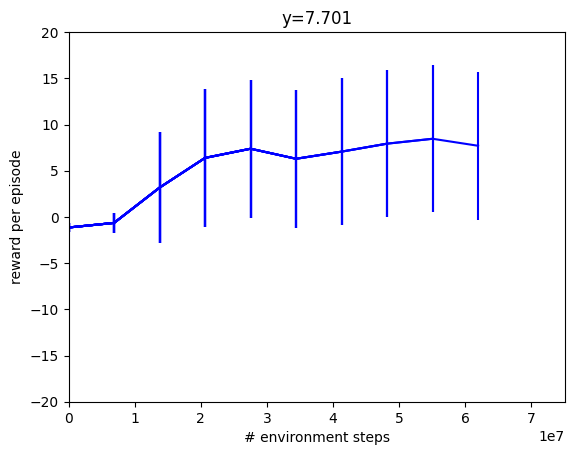

time to jit: 0:01:25.453055
time to train: 0:17:36.170665


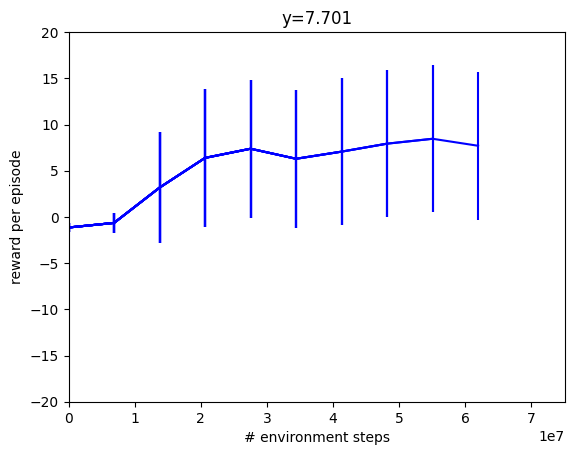

In [15]:
from datetime import datetime
import functools
from IPython.display import clear_output, display
import matplotlib.pyplot as plt
import mediapy as media
import jax
import jax.numpy as jnp
import numpy as np
from ml_collections import config_dict

from mujoco_playground import wrapper
from brax.training.agents.ppo import networks as ppo_networks
from brax.training.agents.ppo import train as ppo
from mujoco_playground.config import dm_control_suite_params

# Progress plots
x_data, y_data, y_dataerr = [], [], []
times = [datetime.now()]
def progress(num_steps, metrics):
    clear_output(wait=True)
    times.append(datetime.now())
    x_data.append(num_steps)
    y_data.append(metrics["eval/episode_reward"])
    y_dataerr.append(metrics["eval/episode_reward_std"])

    plt.xlim([0, ppo_params["num_timesteps"] * 1.25])
    plt.ylim([-20, 20])
    plt.xlabel("# environment steps")
    plt.ylabel("reward per episode")
    plt.title(f"y={y_data[-1]:.3f}")
    plt.errorbar(x_data, y_data, yerr=y_dataerr, color="blue")
    display(plt.gcf())

# Anneal LR
def linear_annealing_lr(init_lr, final_lr, num_timesteps):
    def schedule(step):
        progress = step / num_timesteps
        return init_lr + progress * (final_lr - init_lr)
    return schedule

# PPO training parameters
ppo_params = config_dict.create(
    num_timesteps=60_000_000,
    num_evals=10,
    episode_length=1500,
    normalize_observations=True,
    action_repeat=1,
    unroll_length=30,
    num_minibatches=32,
    num_updates_per_batch=16,
    discounting=0.995,
    learning_rate=linear_annealing_lr(3e-3, 0.25 * 3e-3,  60_000_000),
    entropy_cost=1e-3,
    num_envs=2048,
    batch_size=1024,
)

ppo_training_params = dict(ppo_params)
network_factory = functools.partial(
    ppo_networks.make_ppo_networks,
    policy_hidden_layer_sizes = (128, 128),
    value_hidden_layer_sizes  = (128, 128),
)
network_factory = ppo_networks.make_ppo_networks
if "network_factory" in ppo_params:
    del ppo_training_params["network_factory"]
    network_factory = functools.partial(
        ppo_networks.make_ppo_networks,
        **ppo_params.network_factory
    )

train_fn = functools.partial(
    ppo.train,
    **dict(ppo_training_params),
    network_factory=network_factory,
    progress_fn=progress
)

# Create environment with one drone
env = CrazyflieEnv(scene_path=SCENE_PATH_1_DRONE, num_drones=1)

# Train PPO agent - make_inference_fn is our policy function, params are network parameters, metrics are training stats
# Wrap env for training to match Brax format (e.g. add device and env dimensions to obs)
make_inference_fn, params, metrics = train_fn(
    environment=env,
    wrap_env_fn=wrapper.wrap_for_brax_training,
)
print(f"time to jit: {times[1] - times[0]}")
print(f"time to train: {times[-1] - times[1]}")

## PPO Test Rollout

In [16]:
env = CrazyflieEnv(scene_path=SCENE_PATH_1_DRONE, num_drones=1)

rollout = rollout_policy(
    env,
    params=params,
    apply_fn=make_inference_fn(params, deterministic=True),
    episode_length=3000,
    seed=42,
    print_logs=False,
    random_reset=False,
    use_brax_policy=True
)

Target: [0. 0. 1.]
Observation shape for 1 drones: (31,)

Total steps: 3001, Final reward: 32.85

Rendering trajectory, target at [0. 0. 1.]...


100%|██████████| 3001/3001 [00:17<00:00, 169.24it/s]


This browser does not support the video tag.


## Save and Download Brax Model

In [17]:
from brax.io import model
from google.colab import files

model.save_params('/content/ppo_params.pkl', params)
files.download('/content/ppo_params.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Load Brax Model

In [ ]:
from brax.io import model

params = model.load_params('/content/ppo_params.pkl')
inference_fn = make_inference_fn(params)

# Custom Multi-Agent PPO (MAPPO) for Multiple Agents

True multi-agent RL: actors see & act on their own observations (+ relative pos to other drones), critic sees global observation and computes a global reward. The actors share parameters/policy (the same policy examines each drone's observations and outputs an action for each drone).

## MAPPO Training setup (also run this cell if loading a model)

In [7]:
import functools
from typing import Any, Callable, Tuple

import jax
import jax.numpy as jnp
import numpy as np
import optax
import flax.linen as nn
from flax.training.train_state import TrainState
from dataclasses import dataclass
from datetime import datetime
from IPython.display import clear_output
import matplotlib.pyplot as plt

NUM_DRONES = 2

# ---------------------------
# Hyperparameters / settings
# ---------------------------
NUM_ENVS = 2048
NUM_UPDATES = 1200
ROLLOUT_STEPS = 128

NUM_EPOCHS = 2
NUM_MINIBATCHES = 16
MINI_BATCH_SIZE = NUM_ENVS * ROLLOUT_STEPS // NUM_MINIBATCHES

EPISODE_LENGTH = 1500

# Discounting
GAMMA = 0.995
GAE_LAMBDA = 0.95

# Annealing LR
LR = 3e-3
LR_FINAL = LR * 0.25

CLIP_EPS = 0.2
ENTROPY_COEF = 1e-3
VF_COEF = 0.5
MAX_GRAD_NORM = 0.5

SEED = 42
POLICY_HIDDEN = [128, 128]
# Larger hidden layers for critic since it sees all drone obs
VF_HIDDEN = [256, 256]


# ---------------------------
# Models (Flax)
# ---------------------------

class MLP(nn.Module):
    hidden_sizes: Tuple[int, ...]
    activate_final: bool = False

    @nn.compact
    def __call__(self, x):
        for i, h in enumerate(self.hidden_sizes):
            x = nn.relu(nn.Dense(h)(x))
        if self.activate_final:
            x = nn.relu(x)
        return x

class Actor(nn.Module):
    """Per-agent Gaussian policy: state --> mean, log(std)"""
    hidden_sizes: Tuple[int, ...]
    action_dim: int

    @nn.compact
    def __call__(self, x):
        # x: (..., obs_dim_per_agent)
        h = MLP(self.hidden_sizes)(x)

        # Layers for mean and log_std weights & biases
        mean = nn.Dense(self.action_dim)(h)
        log_std = nn.Dense(self.action_dim)(h)

        # Ensure numerically reasonable range for log_std
        log_std = jnp.clip(log_std, -20.0, 2.0)

        return mean, log_std

@functools.partial(jax.jit, static_argnums=(1,))
def actor_forward(params, apply_fn, per_agent_obs):
    """Decentralized (per-agent) policy update, sharing parameters across agents."""
    # per_agent_obs: (batch, n_agents, per_agent_obs_dim)
    # Compute mean/log_std for each agent independently.
    B, A, D = per_agent_obs.shape
    flat = per_agent_obs.reshape((B * A, D))

    mean, log_std = apply_fn(params, flat)  # shapes (B*A, action_dim)
    mean = mean.reshape((B, A, -1))
    log_std = log_std.reshape((B, A, -1))

    return mean, log_std


class CentralizedCritic(nn.Module):
    """Takes global joint observation (all agents concatenated) -> scalar value."""
    hidden_sizes: Tuple[int, ...]
    @nn.compact
    def __call__(self, x):
        h = MLP(self.hidden_sizes)(x)
        v = nn.Dense(1)(h)
        return jnp.squeeze(v, -1)  # (batch,)

@functools.partial(jax.jit, static_argnums=(1,))
def critic_forward(params, apply_fn, global_obs):
    """Centralized critic update, sees all observations and computes centralized reward."""
    # global_obs: (batch, per_env_obs_dim)
    return apply_fn(params, global_obs)  # (batch,)

# ---------------------------
# TrainState wrappers, define as pytree
# ---------------------------

# https://flax.readthedocs.io/en/latest/_modules/flax/training/train_state.html
@jax.tree_util.register_pytree_node_class
@dataclass
class PPOTrainState:
    policy_state: TrainState
    value_state: TrainState
    env_steps: jnp.ndarray  # shape (NUM_ENVS,), int32
    ep_returns: jnp.ndarray  # shape (NUM_ENVS,)

    def tree_flatten(self):
        children = (self.policy_state, self.value_state, self.env_steps, self.ep_returns)
        return children, None

    @classmethod
    def tree_unflatten(cls, aux_data, children):
        return cls(*children)

# ---------------------------
# Helpers
# ---------------------------

def gaussian_log_prob(mean, log_std, action):
    # mean, log_std, action shapes: (..., action_dim)
    var = jnp.exp(2.0 * log_std)
    logp = -0.5 * (((action - mean) ** 2) / (var + 1e-8) + 2 * log_std + jnp.log(2 * jnp.pi))
    return jnp.sum(logp, axis=-1)  # sum over action dim


# Safe scalar clipping (for jax.grad stability)
def clip_by_global_norm(updates, max_norm):
    g_norm = jnp.sqrt(sum([jnp.sum(jnp.square(p)) for p in jax.tree_util.tree_leaves(updates)]))
    trigger = g_norm < max_norm
    coef = jnp.where(trigger, 1.0, max_norm / (g_norm + 1e-6))
    return jax.tree_util.tree_map(lambda p: p * coef, updates)

# ---------------------------
# Vectorized environment functions
# ---------------------------

# Create env and infer shapes
def make_env_and_infer():
    env = CrazyflieEnv()
    key = jax.random.PRNGKey(0)
    st = env.reset(key)
    obs = st.obs

    # obs is flattened across drones: shape (per_env_obs_dim,)
    per_env_obs_dim = obs.shape[0]
    action_dim = env.action_size  # total action size (flat, across drones)

    # Per agent obs dimension
    per_agent_obs_dim = per_env_obs_dim // NUM_DRONES

    return env, per_env_obs_dim, per_agent_obs_dim, action_dim

env, PER_ENV_OBS_DIM, PER_AGENT_OBS_DIM, ACTION_DIM = make_env_and_infer()

# Vectorized reset and step across num_envs
@functools.partial(jax.jit, static_argnums=0)
def vec_reset(env, rngs):
    """Reset env(s) based on rng key(s)"""
    return jax.vmap(lambda k: env.reset(k))(rngs)

@functools.partial(jax.jit, static_argnums=0)
def vec_step(env, states, actions):
    """
    Step env(s)

    Parameters
    -----------
    states: pytree of length num_envs
    actions: flattened (num_envs, action_dim)

    """
    return jax.vmap(lambda s, a: env.step(s, a))(states, actions)



# ---------------------------
# Training (also handles PPO loss and rollout)
# ---------------------------

def create_train_state(rng, num_updates):
    # initialize actor and critic parameters
    rng1, rng2 = jax.random.split(rng)
    # Policy params: we expect to pass per-agent obs shape (PER_AGENT_OBS_DIM)
    actor_module = Actor(hidden_sizes=tuple(POLICY_HIDDEN), action_dim=ACTION_SIZE_PER_DRONE)
    critic_module = CentralizedCritic(hidden_sizes=tuple(VF_HIDDEN))

    dummy_agent_obs = jnp.zeros((1, PER_AGENT_OBS_DIM))
    dummy_global_obs = jnp.zeros((1, PER_ENV_OBS_DIM))

    actor_params = actor_module.init(rng1, dummy_agent_obs)
    critic_params = critic_module.init(rng2, dummy_global_obs)

    # Anneal LR
    lr_schedule = optax.linear_schedule(
        init_value=LR,
        end_value=LR_FINAL,
        transition_steps=num_updates
    )

    policy_tx = optax.chain(
        optax.clip_by_global_norm(MAX_GRAD_NORM),
        optax.adam(lr_schedule),
    )
    value_tx = optax.chain(
        optax.clip_by_global_norm(MAX_GRAD_NORM),
        optax.adam(lr_schedule),
    )

    policy_state = TrainState.create(apply_fn=actor_module.apply, params=actor_params, tx=policy_tx)
    value_state = TrainState.create(apply_fn=critic_module.apply, params=critic_params, tx=value_tx)
    env_steps = jnp.zeros((NUM_ENVS,), dtype=jnp.int32)
    ep_returns = jnp.zeros((NUM_ENVS,), dtype=jnp.float32)

    return PPOTrainState(
        policy_state=policy_state,
        value_state=value_state,
        env_steps=env_steps,
        ep_returns=ep_returns
    ), actor_module, critic_module

## MAPPO Training

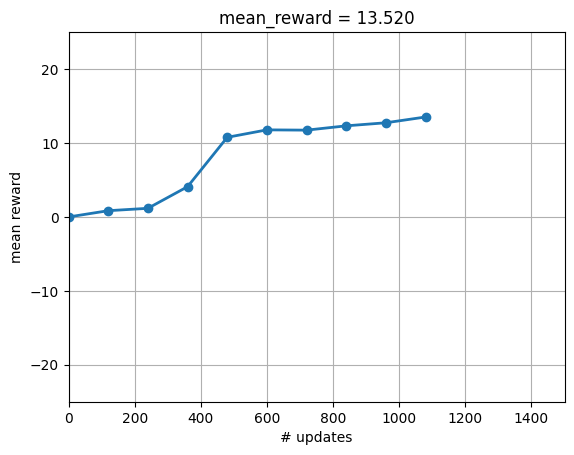

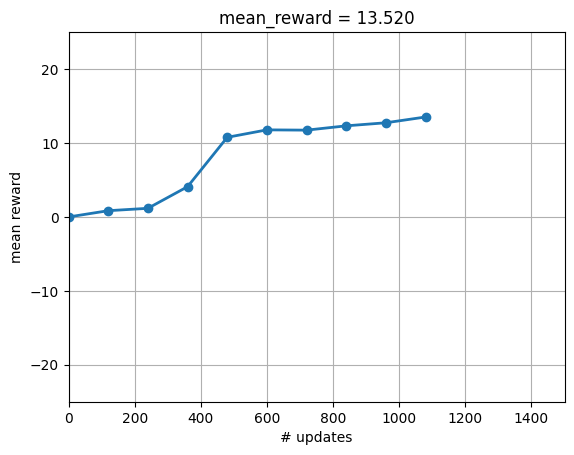

In [8]:
def train(num_updates=NUM_UPDATES, progress_fn=lambda *args: None):
    rng = jax.random.PRNGKey(SEED)
    rng, init_rng = jax.random.split(rng)

    # Create parameters + optimizer state
    train_state, actor_module, critic_module = create_train_state(init_rng, num_updates)

    # Initialize vectorized environments
    rng, *sub = jax.random.split(rng, NUM_ENVS + 1)
    env_states = vec_reset(env, jnp.stack(sub))

    # --------------------------------------------------------------
    # 1. Define GAE function
    # --------------------------------------------------------------
    @jax.jit
    def gae_advantages(rewards, values, dones, gamma=GAMMA, lam=GAE_LAMBDA):
        """
        rewards: (T, N)
        values:  (T+1, N) --> Extra last value for bootstrap
        dones:   (T, N)   --> 0/1 floats or bools

        returns:
          advantages: (T, N)
          returns:    (T, N)  == advantages + values[:-1]
        """

        # Reverse sequences for backward scan
        rewards_r = rewards[::-1]
        values_t_r = values[:-1][::-1]   # values[t] reversed
        values_tp1_r = values[1:][::-1]  # values[t+1] reversed
        dones_r = dones[::-1]

        init = jnp.zeros_like(values[0])  # shape (N,)

        def scan_fn(carry, elems):
            # Carry: advantage_{t+1} (in reversed time)
            r, v, vnext, done = elems
            nonterminal = 1.0 - done
            delta = r + gamma * vnext * nonterminal - v
            adv = delta + gamma * lam * nonterminal * carry
            return adv, adv  # new carry, output advantage

        # Scan over reversed timesteps
        _, advs_rev = jax.lax.scan(
            scan_fn,
            init,
            (rewards_r, values_t_r, values_tp1_r, dones_r),
        )

        # Reverse back to original time order
        advantages = advs_rev[::-1]
        returns = advantages + values[:-1]

        return advantages, returns


    # --------------------------------------------------------------
    # 2. Define Rollout step: Using Jax scan & carry, no rollout buffer
    # --------------------------------------------------------------
    def rollout_step(carry, _):
        # Read carry from previous state, create keys
        env_states, train_state, rng = carry
        rng, step_key, reset_key = jax.random.split(rng, 3)

        # Read observation
        obs = env_states.obs
        per_agent_obs = obs.reshape((NUM_ENVS, NUM_DRONES, PER_AGENT_OBS_DIM))

        # Sample action from the policy using per-agent (decentralized) obs
        mean, log_std = actor_forward(
            train_state.policy_state.params,
            train_state.policy_state.apply_fn,
            per_agent_obs,
        )
        eps = jax.random.normal(step_key, mean.shape)
        actions_per_agent = mean + jnp.exp(log_std) * eps
        log_prob_per_agent = gaussian_log_prob(mean, log_std, actions_per_agent)
        log_prob_per_env = jnp.sum(log_prob_per_agent, axis=1)

        # Compute value of current state using global (centralized) obs
        values = critic_forward(
            train_state.value_state.params,
            train_state.value_state.apply_fn,
            obs,
        )

        # Step the environment with flat action array
        flat_actions = actions_per_agent.reshape((NUM_ENVS, -1))
        next_env_states = vec_step(env, env_states, flat_actions)

        # Detect episode termination: terminate episode if any one drone terminates
        env_steps = train_state.env_steps + 1
        truncated = env_steps >= EPISODE_LENGTH
        done = jnp.logical_or(next_env_states.done.reshape(NUM_ENVS), truncated)

        # Reset terminated envs where necessary
        reset_keys = jax.random.split(reset_key, NUM_ENVS)
        reset_states = vec_reset(env, reset_keys)
        def apply_reset(new, reset):
            """
            Helper to conditionally go to next step or reset based on done and
            broadcast done to match the shape of the leaf in tree (can vary).
            PyTrees: https://docs.jax.dev/en/latest/pytrees.html
            """
            leaf_ndim = new.ndim
            # Add extra dimensions based on leaf dimension
            cond = done.reshape((NUM_ENVS,) + (1,) * (leaf_ndim - 1))
            return jnp.where(cond, reset, new)

        # Conditionally go to next step state or reset state based on apply_reset()
        final_env_states = jax.tree_util.tree_map(
            apply_reset,
            next_env_states,
            reset_states,
        )

        # Update other state info
        env_steps = jnp.where(done, 0, env_steps)
        ep_returns = train_state.ep_returns + next_env_states.reward
        ep_returns = jnp.where(done, 0.0, ep_returns)

        # Store updated state
        train_state = PPOTrainState(
            policy_state=train_state.policy_state,
            value_state=train_state.value_state,
            env_steps=env_steps,
            ep_returns=ep_returns
        )

        transition = (
            obs,
            flat_actions,
            log_prob_per_env,
            next_env_states.reward.reshape(NUM_ENVS),
            done,
            values,
        )
        return (final_env_states, train_state, rng), transition


    # --------------------------------------------------------------
    # 3. Define Minibatch update & PPO loss functions
    # --------------------------------------------------------------
    def minibatch_update(train_state, batch):
        mb_obs, mb_actions, mb_old_log_prob, mb_adv, mb_ret = batch
        mb_shape = mb_obs.shape[0]
        mb_per_agent_obs = mb_obs.reshape((mb_shape, NUM_DRONES, PER_AGENT_OBS_DIM))

        def policy_loss_fn(params):
            # Compute action based on observation
            mean, log_std = actor_forward(
                params, train_state.policy_state.apply_fn, mb_per_agent_obs
            )
            mean_flat = mean.reshape((mb_shape * NUM_DRONES, ACTION_SIZE_PER_DRONE))
            log_std_flat = log_std.reshape((mb_shape * NUM_DRONES, ACTION_SIZE_PER_DRONE))
            act_flat = mb_actions.reshape((mb_shape * NUM_DRONES, ACTION_SIZE_PER_DRONE))

            # Compare ratio of old log prob to new log prob
            log_prob_flat = gaussian_log_prob(mean_flat, log_std_flat, act_flat)
            log_prob = log_prob_flat.reshape((mb_shape, NUM_DRONES)).sum(axis=1)
            ratio = jnp.exp(log_prob - mb_old_log_prob)

            # Compute clipped objective and policy loss
            unclipped = ratio * mb_adv
            clipped = jnp.clip(ratio, 1 - CLIP_EPS, 1 + CLIP_EPS) * mb_adv
            objective = -jnp.mean(jnp.minimum(unclipped, clipped))
            entropy = ENTROPY_COEF * jnp.mean(jnp.sum(0.5 * (jnp.log(2*jnp.pi) + 1) + log_std_flat, axis=-1))

            return objective - entropy

        def value_loss_fn(v_params):
            v = critic_forward(v_params, train_state.value_state.apply_fn, mb_obs)
            return jnp.mean((v - mb_ret) ** 2) * VF_COEF

        pi_loss, pi_grads = jax.value_and_grad(policy_loss_fn)(
            train_state.policy_state.params
        )
        vf_loss, vf_grads = jax.value_and_grad(value_loss_fn)(
            train_state.value_state.params
        )

        # Apply updates
        pi_updates, pi_opt_state = train_state.policy_state.tx.update(
            pi_grads, train_state.policy_state.opt_state
        )
        vf_updates, vf_opt_state = train_state.value_state.tx.update(
            vf_grads, train_state.value_state.opt_state
        )

        new_train_state = PPOTrainState(
            policy_state=train_state.policy_state.replace(
                params=optax.apply_updates(train_state.policy_state.params, pi_updates),
                opt_state=pi_opt_state,
            ),
            value_state=train_state.value_state.replace(
                params=optax.apply_updates(train_state.value_state.params, vf_updates),
                opt_state=vf_opt_state,
            ),
            env_steps=train_state.env_steps,
            ep_returns=train_state.ep_returns
        )

        return new_train_state, None

    # --------------------------------------------------------------
    # 4. Define PPO update (epochs × minibatches) via lax.scan
    # --------------------------------------------------------------
    def ppo_update(train_state, traj, adv, ret, rng):
        # Flatten rollout
        T = ROLLOUT_STEPS
        E = NUM_ENVS
        B = T * E # total transitions for this update

        obs = traj[0].reshape((B, PER_ENV_OBS_DIM))
        acts = traj[1].reshape((B, ACTION_DIM))
        old_logp = traj[2].reshape((B,))
        adv = adv.reshape((B,))
        ret = ret.reshape((B,))

        # Normalize advantages
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        # Generate minibatch indices inside JIT
        rng, perm_key = jax.random.split(rng)
        idx = jax.random.permutation(perm_key, B)
        num_minibatches = B // MINI_BATCH_SIZE

        idx = idx[: num_minibatches * MINI_BATCH_SIZE]
        idx = idx.reshape((num_minibatches, MINI_BATCH_SIZE))

        def minibatch_scan_fn(ts, mb_idx):
            batch = (
                obs[mb_idx],
                acts[mb_idx],
                old_logp[mb_idx],
                adv[mb_idx],
                ret[mb_idx],
            )
            return minibatch_update(ts, batch)

        # Repeat across NUM_EPOCHS
        def epoch_scan_fn(ts, _):
            ts, _ = jax.lax.scan(minibatch_scan_fn, ts, idx)
            return ts, None

        train_state, _ = jax.lax.scan(epoch_scan_fn, train_state, None, length=NUM_EPOCHS)

        return train_state, rng

    # --------------------------------------------------------------
    # 5. Define the MAPPO training update function
    # --------------------------------------------------------------
    @jax.jit
    def training_step(train_state, env_states, rng):
        # Collect rollout
        (env_states, train_state, rng), traj = jax.lax.scan(
            rollout_step,
            (env_states, train_state, rng),
            None,
            length=ROLLOUT_STEPS,
        )

        obs, acts, logp, rewards, dones, values = traj

        # For each timestep, compute advantages for the actor policy update
        # Use GAE to bootstrap non-terminal episodes
        last_values = critic_forward(
            train_state.value_state.params,
            train_state.value_state.apply_fn,
            obs[-1] # Global obs
        )
        values = jnp.concatenate([values, last_values[None, :]], axis=0)
        adv, ret = gae_advantages(rewards, values, dones)

        # PPO update (MAPPO update, critic receives full obs downstream)
        train_state, rng = ppo_update(train_state, traj, adv, ret, rng)

        metrics = {
            "mean_reward": jnp.mean(train_state.ep_returns),
        }
        return train_state, env_states, rng, metrics

    # --------------------------------------------------------------
    # 6. Run Updates
    # --------------------------------------------------------------
    training_step_jit = jax.jit(training_step)
    for update in range(NUM_UPDATES):
        train_state, env_states, rng, metrics = training_step_jit(
            train_state, env_states, rng
        )
        if update % max(1, NUM_UPDATES // 10) == 0:
            progress_fn(update, metrics)

    return train_state


# ---------------------------
# Entry point
# ---------------------------

# Progress plots
x_data, y_data, y_dataerr = [], [], []
times = [datetime.now()]
def progress(update, metrics):
    clear_output(wait=True)

    times.append(datetime.now())
    x_data.append(update)
    y_data.append(metrics["mean_reward"])

    plt.clf()
    plt.plot(x_data, y_data, marker='o', linewidth=2)

    plt.xlim([0, NUM_UPDATES * 1.25])
    plt.ylim([-25, 25])
    plt.xlabel("# updates")
    plt.ylabel("mean reward")
    plt.title(f"mean_reward = {y_data[-1]:.3f}")

    plt.grid(True)
    display(plt.gcf())


final_state = train(num_updates=NUM_UPDATES, progress_fn=progress)

## MAPPO Example Rollout

In [9]:
env = CrazyflieEnv()

rollout = rollout_policy(
    env,
    params=final_state.policy_state.params,
    apply_fn=final_state.policy_state.apply_fn,
    episode_length=3000,
    seed=42,
    print_logs=False,
    random_reset=False,
    target=jnp.array([0.0, 0.0, 0.5])
)

Target: [0.  0.  0.5]
Observation shape for 2 drones: (68,)

Total steps: 733, Final reward: 8.15

Rendering trajectory, target at [0.  0.  0.5]...


100%|██████████| 733/733 [00:02<00:00, 301.25it/s]


This browser does not support the video tag.


# MAPPO Model Utilities (save/download/run/test)

Model checkpoints for MAPPO can be saved/downloaded/uploaded below. The load cell loads a checkpoint and runs an evaluation.

### Save Model

In [10]:
import os
from flax.training import checkpoints

ckpt_dir = os.path.abspath("./checkpoints")

checkpoints.save_checkpoint(
    ckpt_dir=ckpt_dir,
    target=final_state,
    step=NUM_UPDATES,
    overwrite=True
)

'/content/checkpoints/checkpoint_1200'

### Download Saved Model

In [11]:
import shutil
import os
from google.colab import files

ckpt_dir = os.path.abspath("./checkpoints")
shutil.make_archive("checkpoints", "zip", ckpt_dir)
files.download("checkpoints.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Upload Model Checkpoint and Import State (Load Model)

In [12]:
import os
import zipfile
from google.colab import files
from flax.training import checkpoints
from flax import serialization


# Checkpoint directory for trained model
# Assuming we are loading a model that was trained with above config (NUM_UPDATES), adjust as needed
NUM_MODEL_UPDATES = NUM_UPDATES
checkpoint_dir = os.path.abspath(f"./checkpoint_{NUM_MODEL_UPDATES}")


print("Please upload your checkpoints.zip file.")
uploaded = files.upload()
zip_name = next(iter(uploaded))

# Overwrite ./checkpoint_{NUM_MODEL_UPDATES} with new checkpoint file
print(f"Unzipping {zip_name} ...")
with zipfile.ZipFile(zip_name, "r") as z:
    z.extractall(".")

print("Checkpoint extracted.")


# Load checkpoint
print("Loading checkpoint...")
init_rng = jax.random.PRNGKey(0)
init_state, _, _ = create_train_state(init_rng, num_updates=NUM_UPDATES)
loaded_state = checkpoints.restore_checkpoint(
    ckpt_dir=checkpoint_dir,
    target=init_state,
)

# Deterministic inference fn for one env
def inference_fn(obs_per_agent):
    apply_fn = loaded_state.policy_state.apply_fn
    params = loaded_state.policy_state.params
    mean, _ = apply_fn(params, obs_per_agent)
    return mean

jit_inference = jax.jit(inference_fn)

print("Model successfully loaded.")

Please upload your checkpoints.zip file.


Saving checkpoints (1).zip to checkpoints (1).zip
Unzipping checkpoints (1).zip ...
Checkpoint extracted.
Loading checkpoint...
Model successfully loaded.


## Test Loaded MAPPO Model for Varying Targets & Seeds

Drones start near the ground, include seeded domain randomization (physics, observation noise) but not random initial pos/rot/vel/ang_vel. See the CrazyflieEnv random_reset parameter.

In [20]:
from tabulate import tabulate


@functools.partial(jax.jit, static_argnums=0)
def vec_reset_targets(env, rngs, targets):
    return jax.vmap(lambda rngs, targets: env.reset(rngs, random_reset=False, target=targets))(rngs, targets)


def test_targets_batched(targets, keys, episode_length=1500):
    env = CrazyflieEnv()
    num_envs = len(targets)

    targets = jnp.stack(targets)
    states = vec_reset_targets(env, keys, targets)

    total_rewards = jnp.zeros(num_envs, dtype=float)
    steps = jnp.zeros(num_envs, dtype=int)
    done_mask = jnp.zeros(num_envs, dtype=bool)

    for t in range(episode_length):

        if bool(jnp.all(done_mask)):
            break

        per_agent_obs = states.obs.reshape(
            (num_envs, NUM_DRONES, PER_AGENT_OBS_DIM)
        )

        actions = jit_inference(per_agent_obs).reshape((num_envs, -1))

        states = vec_step(env, states, actions)
        rewards = states.reward.reshape(num_envs)
        dones = states.done.reshape(num_envs)

        # Update steps and rewards while note done
        total_rewards += rewards * (~done_mask)
        steps = steps + (~done_mask)
        done_mask = jnp.logical_or(done_mask, dones)

    return total_rewards, steps


def make_target_seed_batch(targets, num_seeds, base_seed=0):
    num_targets = len(targets)

    # Repeat each target for every seed
    targets_batched = jnp.repeat(jnp.stack(targets), num_seeds, axis=0)

    # Create PRNG keys
    rng = jax.random.PRNGKey(base_seed)
    rng, *keys = jax.random.split(rng, num_targets * num_seeds + 1)
    keys = jnp.stack(keys)

    return targets_batched, keys, num_targets, num_seeds


def eval_targets_with_seeds(targets, num_seeds, episode_length, base_seed=0):
    targets_batched, keys, T, S = make_target_seed_batch(
        targets, num_seeds, base_seed
    )

    # Run rollout
    returns, steps = test_targets_batched(
        targets_batched,
        keys=keys,
        episode_length=episode_length,
    )

    # Reshape back to [targets, seeds]
    returns = returns.reshape(T, S)
    steps = steps.reshape(T, S)

    return returns, steps


def print_results_table(targets, returns, steps, episode_length):
    stats = {
        "mean_return": returns.mean(axis=1),
        "std_return": returns.std(axis=1),
        "mean_steps": steps.mean(axis=1),
        "failures": (steps < episode_length).sum(axis=1),
    }

    rows = []
    for i, target in enumerate(targets):
        failures = int(stats["failures"][i])
        rows.append([
            i,
            "[" + ", ".join(f"{x:.1f}" for x in target) + "]",
            f"{stats['mean_return'][i]:.2f}",
            f"{stats['std_return'][i]:.2f}",
            f"{stats['mean_steps'][i]:.1f}",
            f"{int(stats["failures"][i])}/{steps.shape[1]}",
        ])

    headers = [
        "Target #",
        "Target (x,y,z)",
        "Mean Return",
        "Std Return",
        "Mean Steps",
        "Failures",
    ]

    print(tabulate(rows, headers=headers, tablefmt="github"))


# (Assuming we trained with TRAINING_POS_RANGE of 2.0m)
test_targets = [
    # Targets within TRAINING_POS_RANGE
    jnp.array([0.0, 0.0, 0.2]),
    jnp.array([0.3, 0.0, 1.0]),
    jnp.array([-0.3, 0.0, 1.0]),
    jnp.array([0.0, 0.3, 1.0]),
    jnp.array([0.0, -0.3, 1.0]),
    jnp.array([0.5, 0.5, 1.2]),
    jnp.array([-0.5, 0.5, 1.2]),
    jnp.array([0.5, -0.5, 1.2]),
    jnp.array([-0.5, -0.5, 1.2]),
    jnp.array([0.0, 0.0, 2.0]),
    jnp.array([1.0, 0.0, 2.0]),
    jnp.array([-1.0, 0.0, 2.0]),
    jnp.array([0.0, 1.0, 2.0]),
    jnp.array([0.0, -1.0, 2.0]),
    jnp.array([2.0, 2.0, 2.0]),
    jnp.array([-2.0, 2.0, 2.0]),
    jnp.array([2.0, -2.0, 2.0]),
    jnp.array([-2.0, -2.0, 2.0]),
    # Targets outside of TRAINING_POS_RANGE
    jnp.array([0.0, 0.0, 3.0]),
    jnp.array([-3.0, 0.0, 3.0]),
    jnp.array([0.0, -3.0, 3.0]),
    jnp.array([3.0, 3.0, 3.0]),
    jnp.array([5.0, 5.0, 5.0]),
    jnp.array([7.0, 7.0, 7.0]),
]

# Test longer episode length (assuming we trained with 1500)
TEST_EPISODE_LENGTH = 3000
NUM_SEEDS = 64

print(f"Testing each target with {NUM_SEEDS} seeds\n")

returns, steps = eval_targets_with_seeds(
    test_targets,
    num_seeds=NUM_SEEDS,
    episode_length=TEST_EPISODE_LENGTH,
)

print_results_table(test_targets, returns, steps, TEST_EPISODE_LENGTH)


Testing each target with 64 seeds

|   Target # | Target (x,y,z)    |   Mean Return |   Std Return |   Mean Steps | Failures   |
|------------|-------------------|---------------|--------------|--------------|------------|
|          0 | [0.0, 0.0, 0.2]   |          5.95 |         0.09 |        703.9 | 64/64      |
|          1 | [0.3, 0.0, 1.0]   |         55.13 |         0.04 |       3000   | 0/64       |
|          2 | [-0.3, 0.0, 1.0]  |         49.63 |         0.1  |       3000   | 0/64       |
|          3 | [0.0, 0.3, 1.0]   |         53.33 |         0.11 |       3000   | 0/64       |
|          4 | [0.0, -0.3, 1.0]  |         53.62 |         0.09 |       3000   | 0/64       |
|          5 | [0.5, 0.5, 1.2]   |         57.37 |         0.02 |       3000   | 0/64       |
|          6 | [-0.5, 0.5, 1.2]  |         53.61 |         0.08 |       3000   | 0/64       |
|          7 | [0.5, -0.5, 1.2]  |         56.82 |         0.6  |       3000   | 0/64       |
|          8 | [-0.5, -0.

## Visualize a Model Rollout for a Given Target and Seed

In [14]:
env = CrazyflieEnv()
TEST_TARGET = jnp.array([0.0, 0.0, 3.0])
TEST_SEED = 42


# Inspect domain randomization for the drone physics, given the seed
rng = jax.random.PRNGKey(TEST_SEED)
env = CrazyflieEnv()
reset_state = env.reset(rng)
mjx_model_2 = env._mjx_model.replace(
    body_mass = reset_state.info["body_mass"],
    body_inertia = reset_state.info["body_inertia"],
    actuator_gainprm = reset_state.info["actuator_gainprm"],
)
model_physics_compare(env._mjx_model, mjx_model_2, TEST_SEED)

print("\n")

# Run and visualize rollout
rollout = rollout_policy(
    env,
    params=loaded_state.policy_state.params,
    apply_fn=loaded_state.policy_state.apply_fn,
    episode_length=3000,
    seed=TEST_SEED,
    print_logs=False,
    random_reset=False,
    target=TEST_TARGET
)

Domain randomization test for seed 42

Mass randomization:
  0.027 --> 0.0261379
  0.027 --> 0.026075

Inertia randomization:
  2.3951e-05 --> 2.4315e-05
  2.3951e-05 --> 2.40078e-05
  3.2347e-05 --> 3.24176e-05
  2.3951e-05 --> 2.21836e-05
  2.3951e-05 --> 2.5167e-05
  3.2347e-05 --> 3.02755e-05

Actuator gain randomization:
  1 --> 1.00719
  1 --> 0.995128
  1 --> 1.00453
  1 --> 0.954945
  1 --> 1.03271
  1 --> 0.980371
  1 --> 1.01557
  1 --> 0.964321


Target: [0. 0. 3.]
Observation shape for 2 drones: (68,)

Total steps: 3001, Final reward: 14.92

Rendering trajectory, target at [0. 0. 3.]...


100%|██████████| 3001/3001 [00:17<00:00, 173.25it/s]


This browser does not support the video tag.
